# **Text and Sentiment Analysis of ECB Speeches**
### *Matteo Severi & Gianluca Antonio Spennacchio*

Central bank communications play a crucial role in shaping market expectations and guiding monetary policy transmission.  
This project applies **Natural Language Processing (NLP)** and **machine learning** techniques to a large corpus of **European Central Bank (ECB)** speeches to quantify the tone of communication over time, distinguishing between *hawkish* (restrictive) and *dovish* (accommodative) rhetoric.

We build a systematic framework combining text preprocessing, sentiment scoring, and supervised classification to extract a **Hawkish–Dovish Index (HD Index)** from ECB discourse and train a **Naive Bayes Classifier** for sentiment prediction.  
This allows us to measure how the ECB’s language evolves across time, from the early years of the Euro, through the global financial and sovereign debt crises, to the post-pandemic tightening cycle.

The analysis proceeds in four main stages.

1. **Data preprocessing**: Tokenization, POS tagging, and lemmatization of all ECB speeches to obtain clean linguistic data.
2. **Sentiment construction**: Application of domain-specific dictionaries to identify *hawkish* and *dovish* terms and compute a continuous HD Index.
3. **Time-series analysis**: Aggregation and smoothing of sentiment signals to reveal shifts in the ECB’s communication tone.
4. **Classification and validation**: Training of a Naive Bayes classifier with K-fold cross-validation to assess the model’s predictive accuracy.

## **0. Package Setup and Imports**

In [ ]:
#!pip install langdetect

In [1]:
import re
import string
import random
import copy as cp

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import nltk
from nltk import word_tokenize, pos_tag
from nltk.corpus import stopwords, words, wordnet
from nltk.stem import WordNetLemmatizer

from langdetect import detect, DetectorFactory
from nltk.classify import NaiveBayesClassifier
from nltk.classify.util import accuracy
from sklearn.model_selection import KFold

In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /Users/gianl/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/gianl/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/gianl/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/gianl/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

## **1. Data Preprocessing**

We begin by importing the full archive of ECB speeches and converting the text into a structured format suitable for analysis. 
The raw text is tokenized, tagged with parts of speech (POS), and lemmatized to reduce words to their canonical form (e.g., “raising” → “raise”).  
All speeches are then cleaned by removing punctuation, digits, and stopwords, while preserving important negations such as *“not”* or *“no reason to expect a rate change”*.

Finally, non-English speeches are discarded using language detection.  
The output is a consistent, high-quality dataset of lemmatized tokens for each ECB speech, ready for sentiment scoring.


In [3]:
df = pd.read_csv(
    #'/Users/matteoseveri/anaconda_projects/P4E_Project/all_ECB_speeches.csv',
    '/Users/gianl/Desktop/UniBo/2° anno/(1) Introduction to Python for Economists/Python project/all_ECB_speeches.csv',
    sep='|',
    encoding='utf-8',
    header=0,
    engine='python',
    quoting=3, 
)

print(df.shape)
df.head(10)

(2940, 5)


,date,speakers,title,subtitle,contents
0,2025-09-30,Piero Cipollone,Innovating for stability: central bank money i...,"Welcome address by Piero Cipollone, Member of ...",SPEECH Innovating for stability: central ba...
1,2025-09-30,Christine Lagarde,Trade wars and central banks: lessons from 2025,"Keynote speech by Christine Lagarde, President...",SPEECH Trade wars and central banks: lesson...
2,2025-09-29,Piero Cipollone,"Digital euro: protecting our freedom, autonomy...","Keynote speech by Piero Cipollone, Member of t...",SPEECH Digital euro: protecting our freedom...
3,2025-09-26,Piero Cipollone,Preparing the future of payments and money: th...,"Keynote speech by Piero Cipollone, Member of t...",SPEECH Preparing the future of payments and...
4,2025-09-17,Piero Cipollone,What resilience takes: strengthening the finan...,"Keynote speech by Piero Cipollone, Member of t...",SPEECH What resilience takes: strengthening...
5,2025-09-17,Piero Cipollone,Central bank money for the digital era,"Slides by Piero Cipollone, Member of the Execu...",NaN
6,2025-09-17,Christine Lagarde,This time is never different: the importance o...,"Welcome address by Christine Lagarde, Presiden...",SPEECH This time is never different: the im...
7,2025-09-15,Christine Lagarde,Stability through balance: rethinking power in...,"Speech by Christine Lagarde, President of the ...",SPEECH Stability through balance: rethinkin...
8,2025-09-15,Isabel Schnabel,Remaining in a good place,"Slides by Isabel Schnabel, Member of the Execu...",NaN
9,2025-09-04,Piero Cipollone,The digital euro: ensuring resilience and incl...,"Introductory statement by Piero Cipollone, Mem...",SPEECH The digital euro: ensuring resili...


In [4]:
df['contents'] = df['contents'].astype(str)
df['tokens'] = df['contents'].apply(word_tokenize)
print(df[['contents', 'tokens']].head())

                                            contents  \
0    SPEECH  Innovating for stability: central ba...   
1    SPEECH  Trade wars and central banks: lesson...   
2    SPEECH  Digital euro: protecting our freedom...   
3    SPEECH  Preparing the future of payments and...   
4    SPEECH  What resilience takes: strengthening...   

                                              tokens  
0  [SPEECH, Innovating, for, stability, :, centra...  
1  [SPEECH, Trade, wars, and, central, banks, :, ...  
2  [SPEECH, Digital, euro, :, protecting, our, fr...  
3  [SPEECH, Preparing, the, future, of, payments,...  
4  [SPEECH, What, resilience, takes, :, strengthe...  


In [5]:
df['tokens'] = df['tokens'].apply(lambda x: x[1:])
print(df[['tokens']].head())

                                              tokens
0  [Innovating, for, stability, :, central, bank,...
1  [Trade, wars, and, central, banks, :, lessons,...
2  [Digital, euro, :, protecting, our, freedom, ,...
3  [Preparing, the, future, of, payments, and, mo...
4  [What, resilience, takes, :, strengthening, th...


In [6]:
df['pos'] = df['tokens'].apply(lambda x: pos_tag(x))
print(df[['tokens', 'pos']].head())

                                              tokens  \
0  [Innovating, for, stability, :, central, bank,...   
1  [Trade, wars, and, central, banks, :, lessons,...   
2  [Digital, euro, :, protecting, our, freedom, ,...   
3  [Preparing, the, future, of, payments, and, mo...   
4  [What, resilience, takes, :, strengthening, th...   

                                                 pos  
0  [(Innovating, VBG), (for, IN), (stability, NN)...  
1  [(Trade, NNP), (wars, NNS), (and, CC), (centra...  
2  [(Digital, NNP), (euro, NN), (:, :), (protecti...  
3  [(Preparing, VBG), (the, DT), (future, NN), (o...  
4  [(What, WP), (resilience, NN), (takes, VBZ), (...  


In [7]:
def nltk_wordnet(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:          
        return None

In [8]:
df['wordnet'] = df['pos'].apply(lambda tagged: [(word, nltk_wordnet(pos)) for (word, pos) in tagged])
print(df[['wordnet']].head())

                                             wordnet
0  [(Innovating, v), (for, None), (stability, n),...
1  [(Trade, n), (wars, n), (and, None), (central,...
2  [(Digital, n), (euro, n), (:, None), (protecti...
3  [(Preparing, v), (the, None), (future, n), (of...
4  [(What, None), (resilience, n), (takes, v), (:...


In [9]:
lemmatizer = WordNetLemmatizer()
df['lemmas'] = df['wordnet'].apply(lambda tagged: [lemmatizer.lemmatize(word, tag) if tag else word for (word, tag) in tagged])
print(df[['tokens', 'lemmas']].head())

                                              tokens  \
0  [Innovating, for, stability, :, central, bank,...   
1  [Trade, wars, and, central, banks, :, lessons,...   
2  [Digital, euro, :, protecting, our, freedom, ,...   
3  [Preparing, the, future, of, payments, and, mo...   
4  [What, resilience, takes, :, strengthening, th...   

                                              lemmas  
0  [Innovating, for, stability, :, central, bank,...  
1  [Trade, war, and, central, bank, :, lesson, fr...  
2  [Digital, euro, :, protect, our, freedom, ,, a...  
3  [Preparing, the, future, of, payment, and, mon...  
4  [What, resilience, take, :, strengthen, the, f...  


In [10]:
hawkish_words = [
    "raise", "increase", "go up", "tighten", "head up", "hike", "move up",
    "put up", "rise", "lift", "boost", "bump up", "augment", "higher",
    "climb", "hawkish", "tight"
]

dovish_words = [
    "cut", "decrease", "go down", "ease", "head down", "slash", "move down",
    "put down", "reduce", "loosen", "slice", "shave", "trim", "lower",
    "drop", "dovish", "loose", "accommodation", "accommodative"
]

negations = [
    "not", "not expected to", "unlikely to", "no reason to",
    "no reason to expect a rate"
]

reference_words = [
    "ecb", "european central bank", "duisenberg", "draghi", "trichet",
    "eurozone", "euro area", "rates"
]

In [11]:
def clean_tokens(df, lem_col, negations):

    stop_words = set(stopwords.words("english"))
    stop_words = {w for w in stop_words if w not in negations}
    cleaned_lemmas = []
    valid_indices = []

    for i, lemmas in enumerate(df[lem_col]):
        if not isinstance(lemmas, list):
            cleaned_lemmas.append([])
            continue

        text_joined = " ".join(lemmas)
        try:
            lang = detect(text_joined)
        except:
            lang = "unknown"

        if lang != "en":
            cleaned_lemmas.append([])
            continue

        temp = []
        for lem in lemmas:
            lem = lem.lower().strip()
            if (
                lem in string.punctuation
                or len(lem) < 2
                or lem.isdigit()
                or re.fullmatch(r"[\W_]+", lem)
            ):
                continue
            if lem in stop_words:
                continue
            temp.append(lem)

        cleaned_lemmas.append(temp)
        valid_indices.append(i)

    df[lem_col] = cleaned_lemmas
    df = df[df[lem_col].map(len) > 0].reset_index(drop=True)

    print(f"Lemmas cleaning complete. Remaining English speeches: {len(df)}")
    return df

In [12]:
df = clean_tokens(df, lem_col='lemmas', negations=negations)
print(df.shape)

Lemmas cleaning complete. Remaining English speeches: 2650
(2650, 9)


## **2. Sentiment Construction**

In this step, each speech is analyzed through **domain-specific dictionaries** of monetary policy language, inspired by the approach proposed in  
**Ellen Tobback, Stefano Nardelli, and David Martens (2017)**, *“Between Hawks and Doves: Measuring Central Bank Communication,” ECB Working Paper Series*.

- **Hawkish terms** (e.g., *raise, tighten, increase, higher*) indicate restrictive or inflation-fighting rhetoric.  
- **Dovish terms** (e.g., *cut, ease, reduce, accommodative*) reflect an expansionary or supportive policy stance.  
- **Negations** are handled explicitly to invert the meaning when phrases such as *“not expected to raise rates”* occur.  
- **Reference words** (e.g., *ECB, euro area, interest rates, Draghi*) ensure that only monetary policy–related sentences are evaluated.

Each speech receives a continuous **Hawkish–Dovish (HD) Index**. The HD Index ranges from −1 (*fully dovish*) to +1 (*fully hawkish*), capturing the relative tone of policy communication within each speech.
This dictionary-based approach allows for a transparent and interpretable mapping between linguistic content and monetary stance.


In [13]:
def hd_index(text, hawkish_words, dovish_words, reference_words, negations):
    sentences = nltk.sent_tokenize(text)
    hawk_sent, dove_sent = 0, 0

    for s in sentences:
        if any(ref in s for ref in reference_words):
            negated = any(neg in s for neg in negations)
            has_hawk = any(h in s for h in hawkish_words)
            has_dove = any(d in s for d in dovish_words)

            if not negated:
                if has_hawk: hawk_sent += 1
                if has_dove: dove_sent += 1

    if (hawk_sent + dove_sent) == 0:
        return 0

    hd = (hawk_sent - dove_sent) / (hawk_sent + dove_sent)
    return hd

In [14]:
df["HD_index"] = df["lemmas"].apply(
    lambda x: hd_index(" ".join(x), hawkish_words, dovish_words, reference_words, negations)
)

In [15]:
print(df['HD_index'].describe())

count    2650.000000
mean       -0.019560
std         0.227657
min        -1.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: HD_index, dtype: float64


## **3. Time-Series Analysis**

Once the Hawkish–Dovish (HD) Index is computed for each speech, we shift from textual to temporal analysis to explore how the ECB’s policy tone evolved over time.  
Each speech is linked to its delivery date, allowing us to construct a chronological sentiment trajectory of central bank communication.

To smooth day-to-day fluctuations and capture persistent shifts in tone, a **120-day rolling mean** is applied to the HD Index.

The time-series reveals a clear cyclical pattern:

- **1999 – 2005 | Neutral Beginnings and First Dovish Turn**  
  The index starts around neutral to slightly hawkish levels, consistent with the ECB’s early mandate to assert credibility and control inflation under Duisenberg.  
  Around 2003, the tone turns decisively dovish, accompanying the first rate cuts of the euro era as growth slowed and inflation pressures eased.  
  Through 2005, communication remains cautious and stability-oriented, marking the end of the ECB’s formative phase.

- **2006 – 2009 | Temporary Rebound and Crisis Reversal**  
  From 2006 to 2008, the index shows a moderate hawkish rebound, aligned with Trichet’s pre-crisis tightening cycle and growing inflation concerns.  
  As the global financial crisis unfolds in late 2008, the tone briefly turns dovish, reflecting the ECB’s initial liquidity interventions.  
  Yet by 2009, the index rebounds sharply, signaling renewed confidence and a return toward a more hawkish communication as stabilization measures take effect.

- **2010 – 2018 | Deep and Prolonged Dovish Phase**  
  Starting in 2010, the HD index enters its longest dovish stretch, reflecting the euro area sovereign-debt crisis and Draghi’s commitment to preserve the euro (*whatever it takes*).  
  After a small rebound in 2014, between 2015–2016 dovishness peaks with the introduction of QE and negative rates, marking the most accommodative stance in ECB history.  
  A brief rebound in 2017 hints at normalization, but the dip in 2018 confirms the persistence of a low-rate regime.

- **2019 – 2025 | Hawkish Peak and Gradual Normalization**  
  From 2019 onward, the index rises steeply, mirroring the post-pandemic recovery and the rapid inflation surge.  
  The peak in 2021–2022 captures the start of the rate-hike cycle, the sharpest hawkish reversal in two decades.  
  Thereafter, the index declines and stabilizes near neutral, reflecting the 2023–2025 environment of cautious normalization and a return to more balanced, data-driven communication.

Despite being able to quantify structural shifts in communication, the **HD Index** does have a limited magnitude and is biased towards dovish sentiment. This being said creating a more complex indentifier goes beyond the scope of this project.

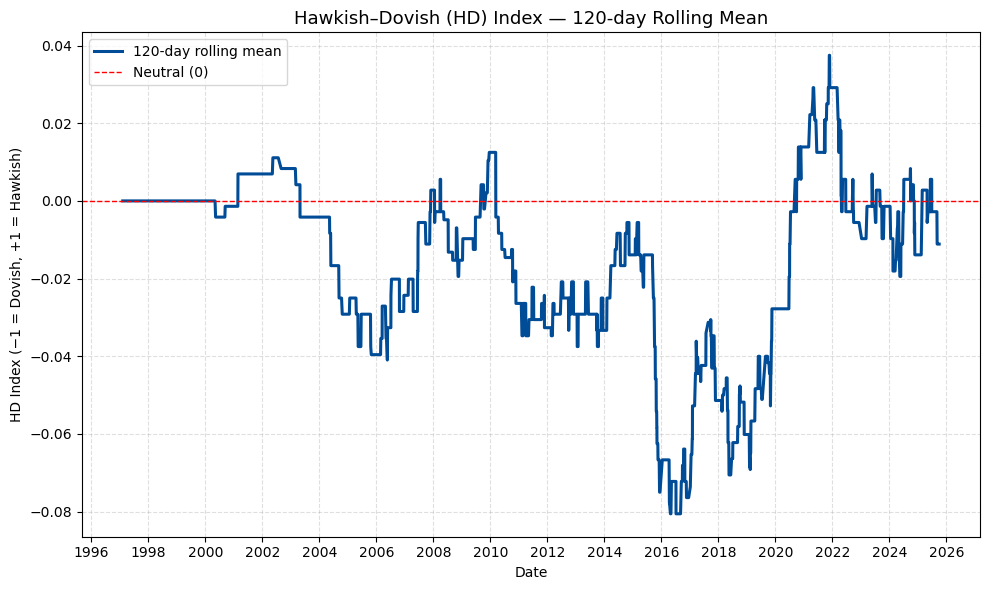

In [16]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

daily = df.groupby('date')['HD_index'].mean().reset_index()

daily['HD_roll120'] = daily['HD_index'].rolling(window=120, min_periods=1).mean()

plt.figure(figsize=(10,6))
plt.plot(daily['date'], daily['HD_roll120'], color='#004C97', linewidth=2.2, label='120-day rolling mean')
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Neutral (0)')

plt.title('Hawkish–Dovish (HD) Index — 120-day Rolling Mean', fontsize=13)
plt.xlabel('Date')
plt.ylabel('HD Index (−1 = Dovish, +1 = Hawkish)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## **4. Classification and Validation**

To validate our sentiment labeling, we transform each speech into a feature dictionary of token occurrences and train a **Naive Bayes classifier** to predict whether a text is *hawkish* or *dovish*.

Model performance is evaluated using **K-fold cross-validation**, testing various split sizes (3, 5, 10, 15, 20 folds) to ensure robustness.  
We report both the mean and standard deviation of classification accuracy across folds.

Cross-validation point to a model accuracy of approximately 87%.


In [17]:
def list_to_dict(ecb_list):
    
    all_ecb_list = []

    for speech, sentiment in ecb_list:
        ecb_dict = {}
        for token in speech:
            ecb_dict[token] = True
        all_ecb_list.append((ecb_dict, sentiment))

    return all_ecb_list

In [18]:
df['sentiment_category'] = np.where(df['HD_index'] >= 0, 'hawkish', 'dovish')
ecb_list = list(zip(df['lemmas'], df['sentiment_category']))
ecb_dict = list_to_dict(ecb_list)

3-fold CV: mean accuracy 0.846 ± 0.087
5-fold CV: mean accuracy 0.871 ± 0.034
10-fold CV: mean accuracy 0.876 ± 0.051
15-fold CV: mean accuracy 0.878 ± 0.037
20-fold CV: mean accuracy 0.882 ± 0.041


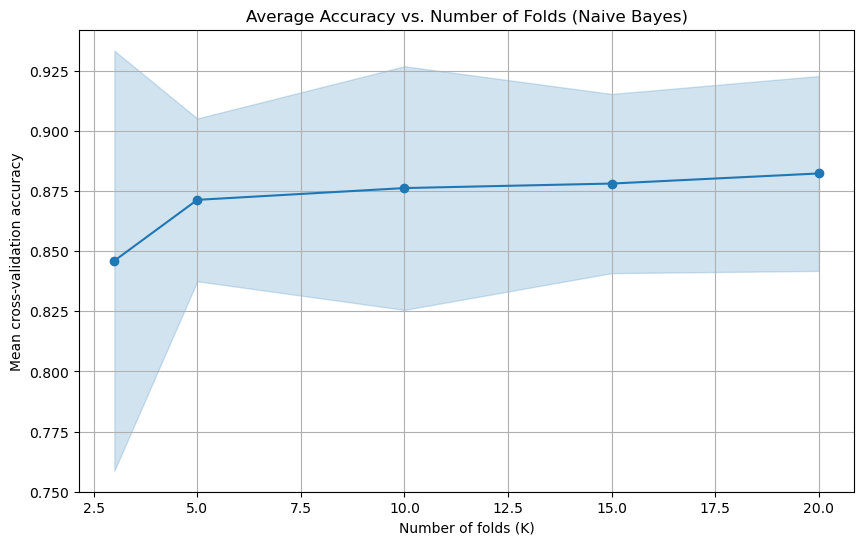

In [19]:
fold_values = [3, 5, 10, 15, 20]
avg_scores = []
std_scores = []

for k in fold_values:
    kf = KFold(n_splits=k, shuffle=True,random_state = 42)
    scores = []

    for train_idx, test_idx in kf.split(ecb_dict):
        train_data = [ecb_dict[i] for i in train_idx]
        test_data  = [ecb_dict[i] for i in test_idx]

        clf = NaiveBayesClassifier.train(train_data)
        scores.append(accuracy(clf, test_data))

    mean_acc = np.mean(scores)
    std_acc  = np.std(scores)

    avg_scores.append(mean_acc)
    std_scores.append(std_acc)

    print(f"{k}-fold CV: mean accuracy {mean_acc:.3f} ± {std_acc:.3f}")

plt.figure(figsize=(10,6))
plt.plot(fold_values, avg_scores, marker='o', color='tab:blue')
plt.title("Average Accuracy vs. Number of Folds (Naive Bayes)")
plt.xlabel("Number of folds (K)")
plt.ylabel("Mean cross-validation accuracy")
plt.grid(True)

plt.fill_between(fold_values, 
                 np.array(avg_scores) - np.array(std_scores),
                 np.array(avg_scores) + np.array(std_scores),
                 color='tab:blue', alpha=0.2)

plt.show()